<a href="https://colab.research.google.com/github/fernandomifflin/API-PELIS-FER/blob/master/Analisis%20de%20datos-MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1) Leer CSV con separador ;
df = pd.read_csv('calidad-del-aire-datos-historicos-diarios.csv', sep=';')

# 2) Eliminar columnas que no aportan
df = df.drop(columns=['index', 'posicion'], errors='ignore')

# 3) Renombrar columnas para quitar las unidades
df = df.rename(columns={
    'CO (mg/m3)': 'CO',
    'NO (ug/m3)': 'NO',
    'NO2 (ug/m3)': 'NO2',
    'O3 (ug/m3)': 'O3',
    'PM10 (ug/m3)': 'PM10',
    'PM25 (ug/m3)': 'PM25',
    'SO2 (ug/m3)': 'SO2'
})

# 4) Copia de respaldo
df_original = df.copy()

print("Dimensiones originales:", df.shape)
print("Columnas finales:", df.columns.tolist())
df.head()

Dimensiones originales: (383249, 12)
Columnas finales: ['Fecha', 'CO', 'NO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2', 'Provincia', 'Estación', 'Latitud', 'Longitud']


,Fecha,CO,NO,NO2,O3,PM10,PM25,SO2,Provincia,Estación,Latitud,Longitud
0,2025-12-21,NaN,1.0,3.0,67.0,5.0,NaN,2.0,Avila,Avila II,40.664722,-4.700833
1,2025-12-21,NaN,3.0,1.0,78.0,6.0,NaN,NaN,Avila,Olvega,NaN,NaN
2,2025-12-21,0.8,12.0,24.0,NaN,5.0,NaN,2.0,Burgos,Burgos 6,NaN,NaN
3,2025-12-21,NaN,5.0,8.0,62.0,8.0,2.0,2.0,Burgos,Miranda de Ebro 2,42.685278,-2.940278
4,2025-12-21,NaN,2.0,5.0,68.0,2.0,1.0,2.0,Burgos,Aranda de Duero 2,41.665556,-3.688889


In [2]:
print("=== INFORMACIÓN GENERAL ===")
df.info()

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe(include='all'))

print("\n=== VARIABLES CATEGÓRICAS ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383249 entries, 0 to 383248
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Fecha      383249 non-null  object 
 1   CO         58126 non-null   float64
 2   NO         356062 non-null  float64
 3   NO2        355507 non-null  float64
 4   O3         240462 non-null  float64
 5   PM10       318225 non-null  float64
 6   PM25       64800 non-null   float64
 7   SO2        289426 non-null  float64
 8   Provincia  383249 non-null  object 
 9   Estación   383249 non-null  object 
 10  Latitud    378394 non-null  float64
 11  Longitud   378394 non-null  float64
dtypes: float64(9), object(3)
memory usage: 35.1+ MB

=== ESTADÍSTICAS DESCRIPTIVAS ===
             Fecha            CO             NO            NO2             O3  \
count       383249  58126.000000  356062.000000  355507.000000  240462.000000   
unique        7493           NaN     

Variables numéricas: ['CO', 'NO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2', 'Latitud', 'Longitud']


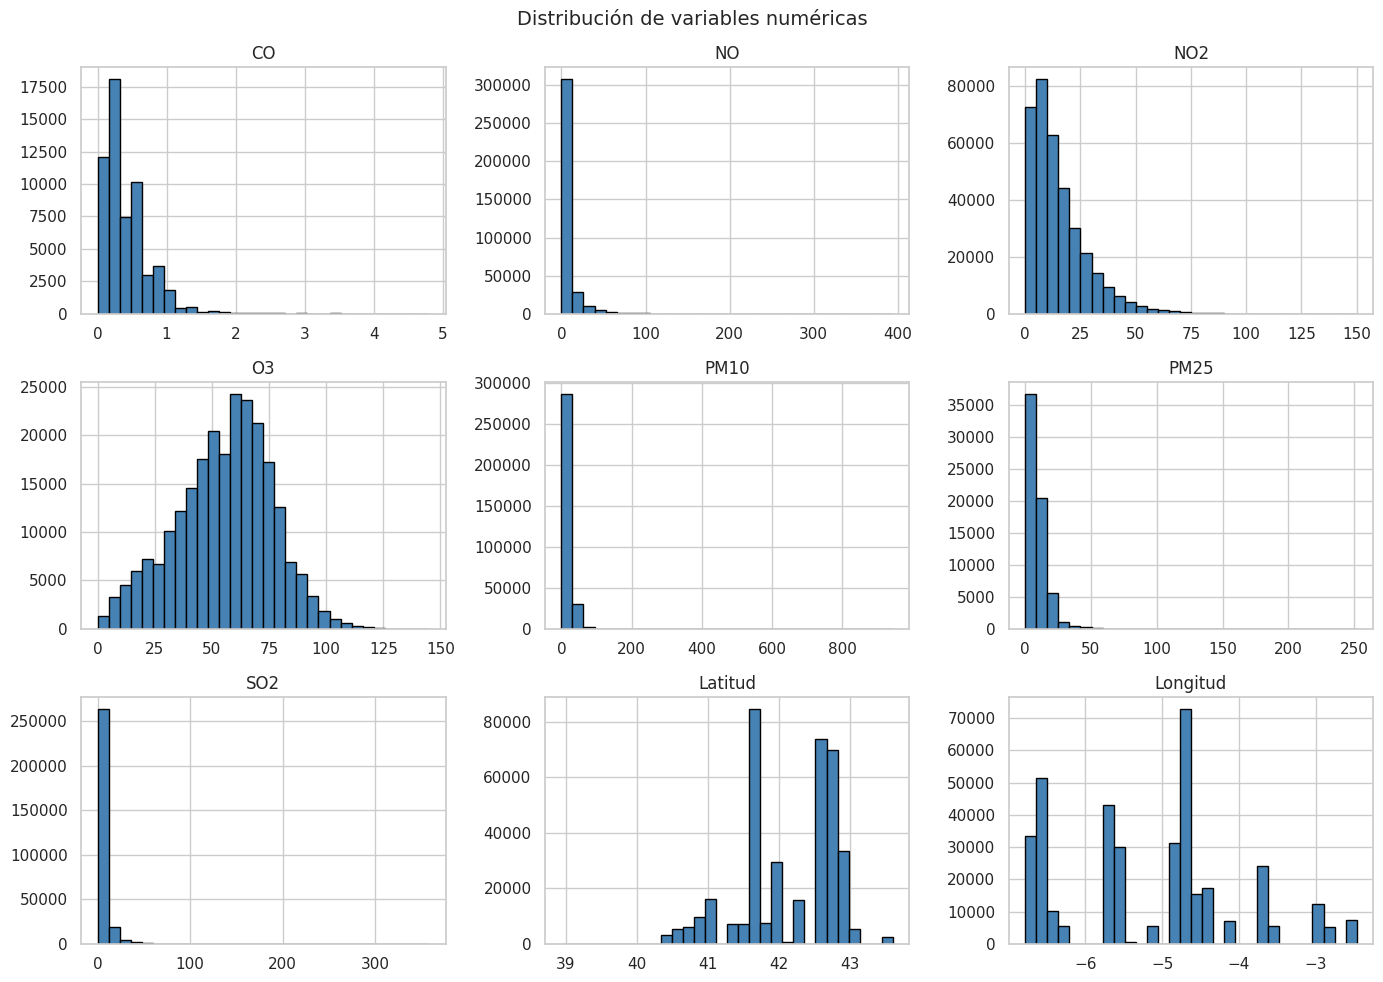

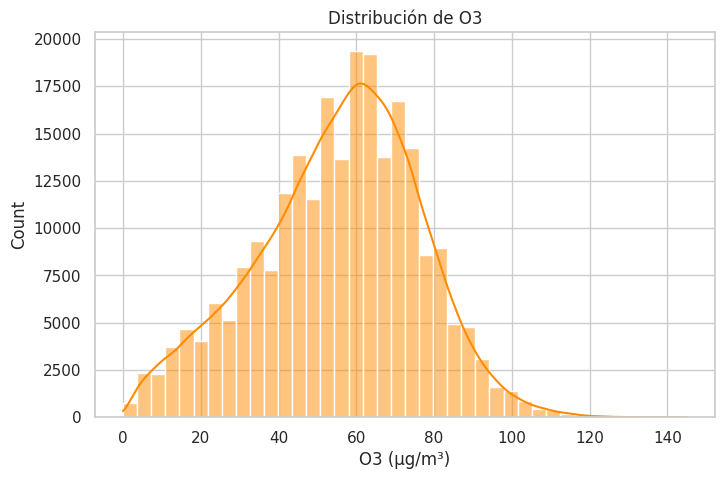

In [3]:
cols_num = df.select_dtypes(include=np.number).columns
print("Variables numéricas:", list(cols_num))

df[cols_num].hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

# Histograma específico de O3
if 'O3' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['O3'].dropna(), bins=40, kde=True, color='darkorange')
    plt.title("Distribución de O3")
    plt.xlabel("O3 (µg/m³)")
    plt.show()

In [4]:
# 1) Fecha a datetime
if 'Fecha' in df.columns:
    df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# 2) Provincia y Estación como categóricas
for col in ['Provincia', 'Estación']:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 3) Asegurar que contaminantes sean numéricos
for col in ['O3', 'NO2', 'NO', 'PM10', 'PM25', 'CO', 'SO2']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("=== TIPOS FINALES ===")
print(df.dtypes)

# Análisis temporal
if 'Fecha' in df.columns:
    df['Año'] = df['Fecha'].dt.year
    print("\nRegistros por año:")
    print(df['Año'].value_counts().sort_index())

=== TIPOS FINALES ===
Fecha        datetime64[ns]
CO                  float64
NO                  float64
NO2                 float64
O3                  float64
PM10                float64
PM25                float64
SO2                 float64
Provincia          category
Estación           category
Latitud             float64
Longitud            float64
dtype: object

Registros por año:
Año
2005    12704
2006    22019
2007    18643
2008    23254
2009    20571
2010    20354
2011    20196
2012    21367
2013    21012
2014    20205
2015    19601
2016    19729
2017    19894
2018    19848
2019    17816
2020    16823
2021    14678
2022    13853
2023    13749
2024    13469
2025    13464
Name: count, dtype: int64


=== VALORES AUSENTES POR COLUMNA ===
            Nulos  Porcentaje
CO         325123       84.83
PM25       318449       83.09
O3         142787       37.26
SO2         93823       24.48
PM10        65024       16.97
NO2         27742        7.24
NO          27187        7.09
Longitud     4855        1.27
Latitud      4855        1.27
Fecha           0        0.00
Provincia       0        0.00
Estación        0        0.00
Año             0        0.00


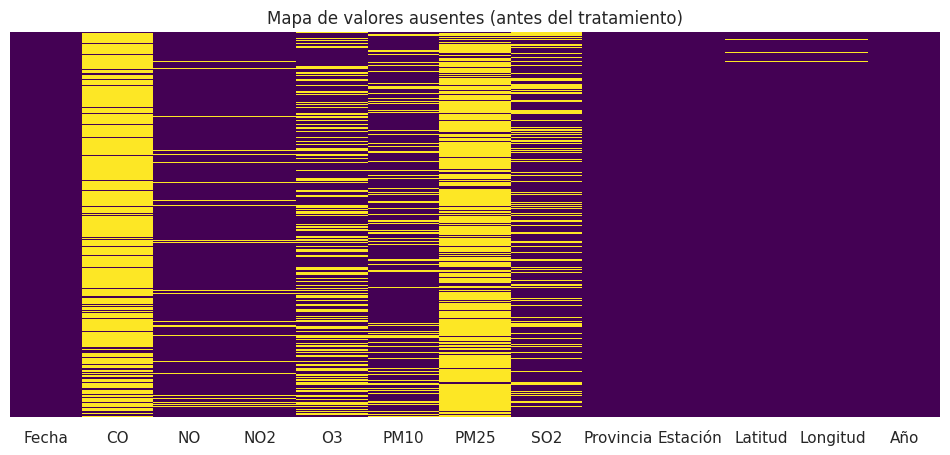

In [5]:
nulos = df.isnull().sum()
porc  = (nulos / len(df)) * 100

tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': porc.round(2)})
tabla_nulos = tabla_nulos.sort_values('Porcentaje', ascending=False)
print("=== VALORES AUSENTES POR COLUMNA ===")
print(tabla_nulos)

# Mapa visual
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Mapa de valores ausentes (antes del tratamiento)")
plt.show()

In [6]:
# 1) Regla: eliminar columnas con más del 50% de nulos
umbral = 50
cols_eliminar = porc[porc > umbral].index.tolist()
print("Columnas eliminadas (>50% nulos):", cols_eliminar)

df = df.drop(columns=cols_eliminar, errors='ignore')

# 2) Imputar nulos restantes con la MEDIA
cols_imputar = df.select_dtypes(include=np.number).columns
for col in cols_imputar:
    n_nulos = df[col].isnull().sum()
    if n_nulos > 0:
        media = df[col].mean()
        df[col] = df[col].fillna(media)
        print(f"{col}: {n_nulos} nulos imputados con media = {media:.2f}")

print("\n=== NULOS RESTANTES ===")
print(df.isnull().sum().to_string())
print("\nTotal de nulos en el DataFrame:", df.isnull().sum().sum())
print("Dimensiones después del tratamiento:", df.shape)

Columnas eliminadas (>50% nulos): ['CO', 'PM25']
NO: 27187 nulos imputados con media = 7.34
NO2: 27742 nulos imputados con media = 14.71
O3: 142787 nulos imputados con media = 55.30
PM10: 65024 nulos imputados con media = 17.22
SO2: 93823 nulos imputados con media = 5.32
Latitud: 4855 nulos imputados con media = 42.13
Longitud: 4855 nulos imputados con media = -5.16

=== NULOS RESTANTES ===
Fecha        0
NO           0
NO2          0
O3           0
PM10         0
SO2          0
Provincia    0
Estación     0
Latitud      0
Longitud     0
Año          0

Total de nulos en el DataFrame: 0
Dimensiones después del tratamiento: (383249, 11)


In [7]:
def detectar_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q2 = data[col].quantile(0.50)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((data[col] < lim_inf) | (data[col] > lim_sup)).sum()
    return {'Variable': col, 'Q1': round(Q1,2), 'Mediana': round(Q2,2),
            'Q3': round(Q3,2), 'IQR': round(IQR,2),
            'Límite inferior': round(lim_inf,2), 'Límite superior': round(lim_sup,2),
            'Outliers': n_out, '% Outliers': round(n_out/len(data)*100, 2)}

cols_analizar = ['O3', 'NO', 'NO2', 'PM10', 'SO2']
resumen_outliers = pd.DataFrame([detectar_outliers_iqr(df, c) for c in cols_analizar])

print("=== RESUMEN DE OUTLIERS POR VARIABLE (método IQR) ===")
print(resumen_outliers.to_string(index=False))

=== RESUMEN DE OUTLIERS POR VARIABLE (método IQR) ===
Variable   Q1  Mediana    Q3   IQR  Límite inferior  Límite superior  Outliers  % Outliers
      O3 52.0     55.3 62.00 10.00            37.00            77.00     78614       20.51
      NO  2.0      4.0  7.34  5.34            -6.00            15.34     40901       10.67
     NO2  6.0     12.0 19.00 13.00           -13.50            38.50     20224        5.28
    PM10 10.0     17.0 20.00 10.00            -5.00            35.00     22243        5.80
     SO2  2.0      5.0  5.32  3.32            -2.98            10.31     30119        7.86


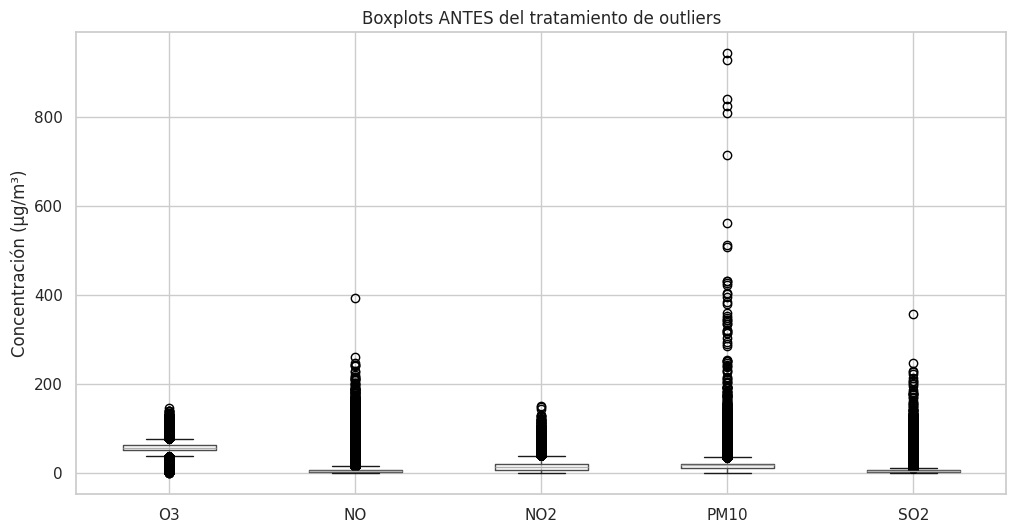

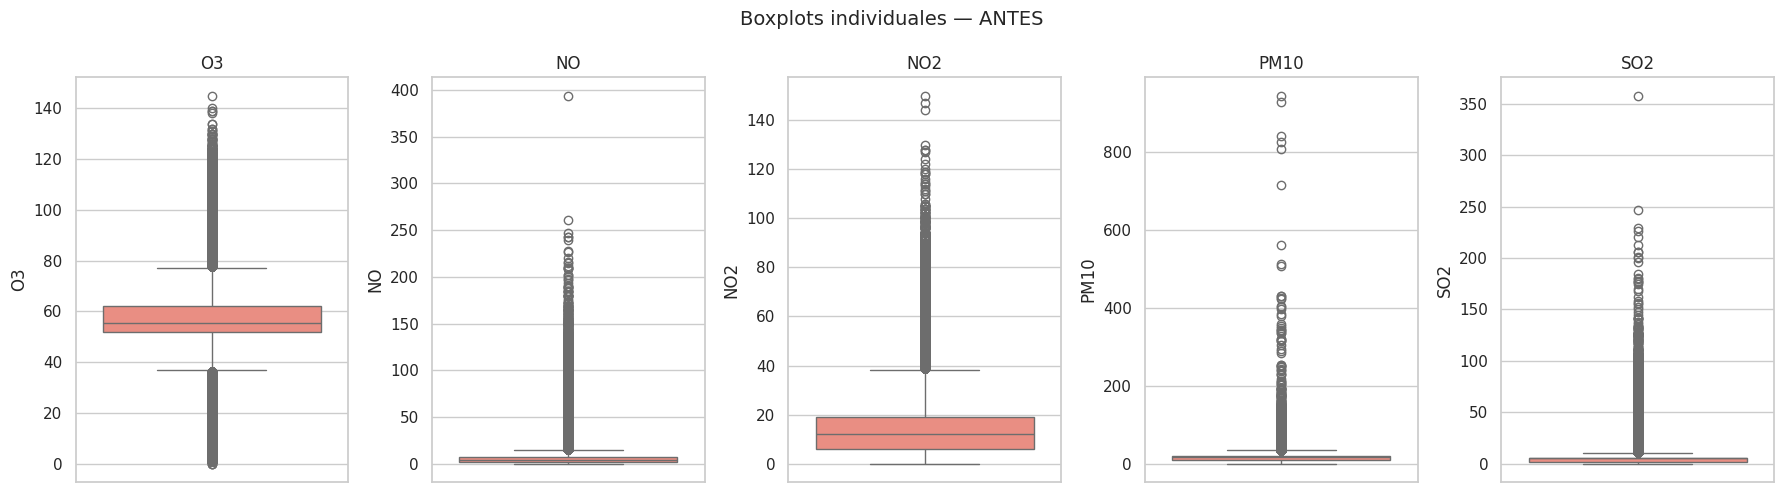

In [8]:
cols_contam = ['O3', 'NO', 'NO2', 'PM10', 'SO2']

# Boxplot múltiple ANTES
plt.figure(figsize=(12, 6))
df[cols_contam].boxplot()
plt.title("Boxplots ANTES del tratamiento de outliers")
plt.ylabel("Concentración (µg/m³)")
plt.show()

# Boxplots individuales
fig, axes = plt.subplots(1, len(cols_contam), figsize=(18, 5))
for ax, col in zip(axes, cols_contam):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(col)
plt.suptitle("Boxplots individuales — ANTES", fontsize=14)
plt.tight_layout()
plt.show()

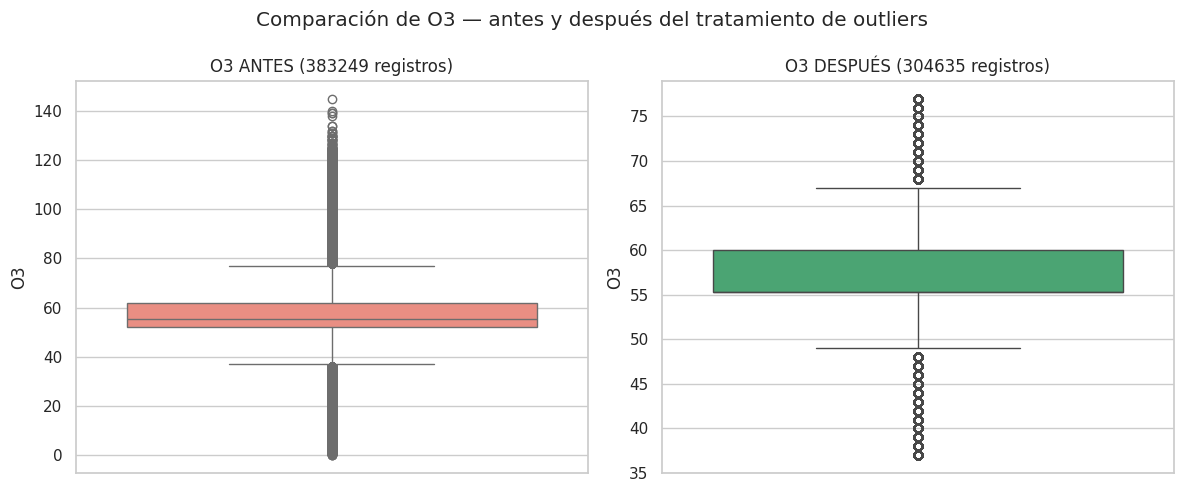

Nota: se conservan los outliers en df (eventos reales).


In [9]:
df_sin_out = df.copy()
Q1 = df['O3'].quantile(0.25)
Q3 = df['O3'].quantile(0.75)
IQR = Q3 - Q1
df_sin_out = df_sin_out[(df_sin_out['O3'] >= Q1 - 1.5*IQR) &
                        (df_sin_out['O3'] <= Q3 + 1.5*IQR)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['O3'], ax=axes[0], color='salmon')
axes[0].set_title(f"O3 ANTES ({len(df)} registros)")
sns.boxplot(y=df_sin_out['O3'], ax=axes[1], color='mediumseagreen')
axes[1].set_title(f"O3 DESPUÉS ({len(df_sin_out)} registros)")
plt.suptitle("Comparación de O3 — antes y después del tratamiento de outliers")
plt.tight_layout()
plt.show()

print("Nota: se conservan los outliers en df (eventos reales).")

=== MATRIZ DE CORRELACIÓN ===
            O3    NO   NO2  PM10   SO2  Latitud  Longitud
O3        1.00 -0.32 -0.36 -0.06 -0.10    -0.07      0.04
NO       -0.32  1.00  0.69  0.30  0.26    -0.08      0.06
NO2      -0.36  0.69  1.00  0.33  0.25    -0.12      0.07
PM10     -0.06  0.30  0.33  1.00  0.15    -0.09      0.09
SO2      -0.10  0.26  0.25  0.15  1.00     0.14     -0.15
Latitud  -0.07 -0.08 -0.12 -0.09  0.14     1.00     -0.30
Longitud  0.04  0.06  0.07  0.09 -0.15    -0.30      1.00


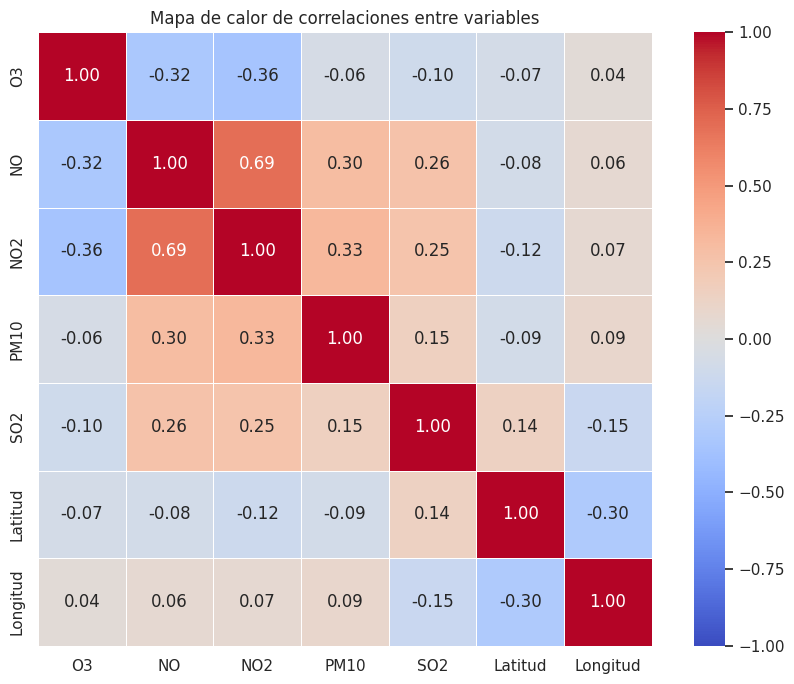

In [10]:
cols_corr = ['O3', 'NO', 'NO2', 'PM10', 'SO2', 'Latitud', 'Longitud']
corr = df[cols_corr].corr()

print("=== MATRIZ DE CORRELACIÓN ===")
print(corr.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Mapa de calor de correlaciones entre variables")
plt.tight_layout()
plt.show()

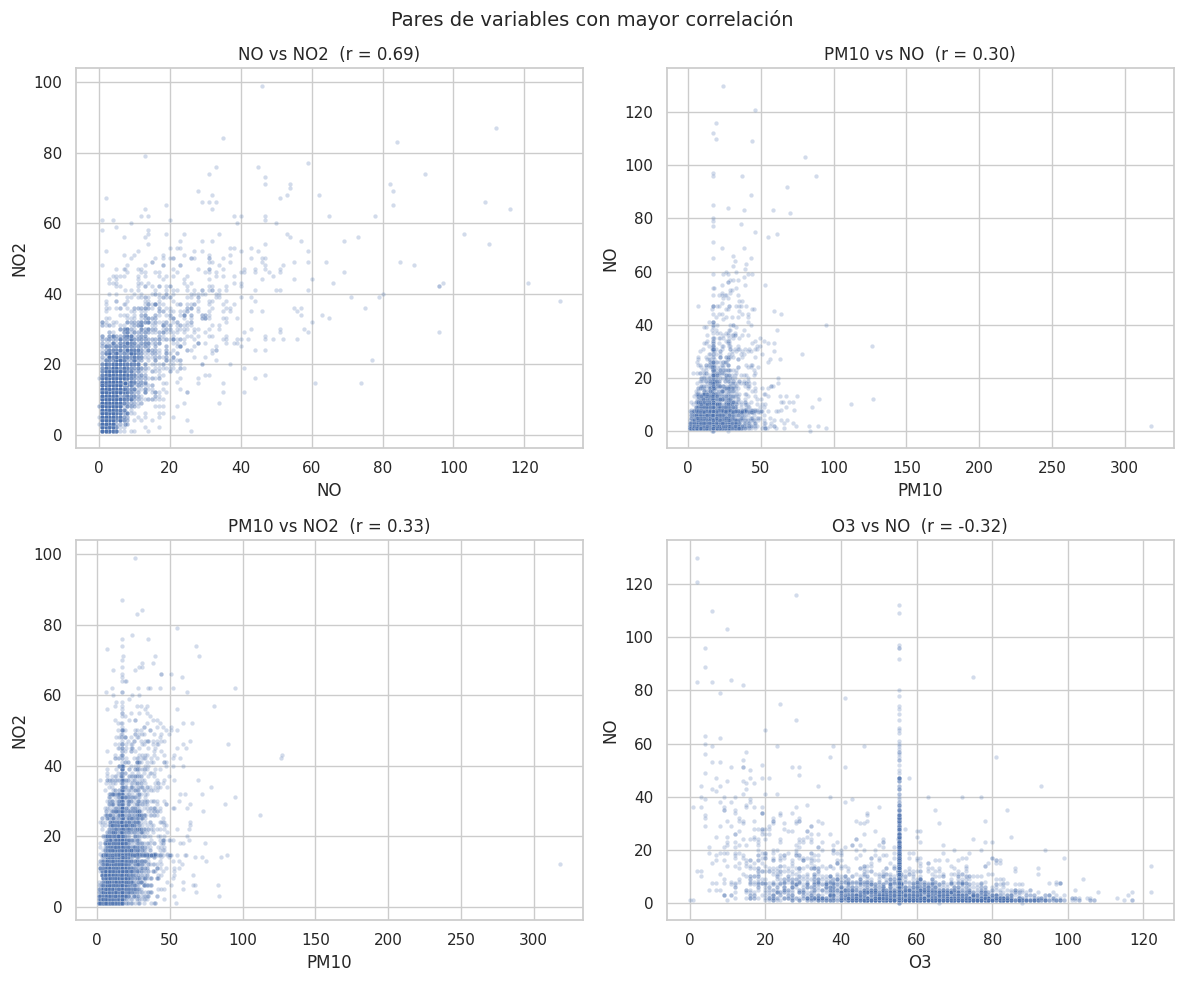

In [11]:
pares = [('NO','NO2'), ('PM10','NO'), ('PM10','NO2'), ('O3','NO')]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (x, y) in zip(axes.flatten(), pares):
    if x in df.columns and y in df.columns:
        sns.scatterplot(data=df.sample(5000, random_state=1),
                        x=x, y=y, alpha=0.25, ax=ax, s=10)
        r = df[[x,y]].corr().iloc[0,1]
        ax.set_title(f"{x} vs {y}  (r = {r:.2f})")
plt.suptitle("Pares de variables con mayor correlación", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
df.to_csv('calidad_aire_limpio.csv', index=False)
print("Archivo guardado:", df.shape)
print("Columnas:", df.columns.tolist())

Archivo guardado: (383249, 11)
Columnas: ['Fecha', 'NO', 'NO2', 'O3', 'PM10', 'SO2', 'Provincia', 'Estación', 'Latitud', 'Longitud', 'Año']
